# Contents

1. Load XGBoost and NN models
2. Explore model performance
3. Ensemble model objective & method
4. Ensemble model implementation
5. Evaluation
6. Plots
7. Appendix

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, log_loss, precision_recall_curve,
    precision_score, recall_score, roc_curve, auc
)

import xgboost as xgb
from tensorflow.keras.models import load_model as keras_load_model

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Load XGBoost and NN models

In [3]:
nn_keras_path = "../models/NN/NN_1to5_all.keras"
nn_model = keras_load_model(nn_keras_path)

In [4]:
xgb_json_path = "../models/XGB/best_xgb_1to5_all.json"
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(xgb_json_path)

## Explore model performance

Based on our validation data, we evaluate the performance of both the XGBoost and NN models. As the two models have different input types, we have separate data preparation pipelines, although the underlying data used is the same.

In [5]:
df_train = pd.read_csv('../data/FEwithMerchants/FE_train_downsampled_1to5_with_merchants.csv')
df_val = pd.read_csv('../data/FEwithMerchants/FE_validation_with_merchants.csv')
df_test = pd.read_csv('../data/FEwithMerchants/FE_test_with_merchants.csv')

In [6]:
df_train_xgb = df_train.copy()
df_train_nn = df_train.copy()

df_val_xgb = df_val.copy()
df_val_nn = df_val.copy()

df_test_xgb = df_test.copy()
df_test_nn = df_test.copy()

### Data preparation for XGBoost

In [7]:
print("Converting categorical columns ...")
categorical_cols = [
    'type', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName', 'transaction_sequence', 'isFlaggedFraud', 'typeHighValueFlag', 'amountBucket', 
]

for col in categorical_cols:
    # Combine categories from both train, val and test, to avoid unseen categories during inference 
    combined_cats = pd.Series(
        pd.concat([df_train_xgb[col], df_val_xgb[col], df_test_xgb[col]], axis=0).dropna().unique()
    )
    categories = sorted(combined_cats.unique())

    df_train_xgb[col] = pd.Categorical(df_train[col], categories=categories)
    df_val_xgb[col]   = pd.Categorical(df_val[col], categories=categories)
    df_test_xgb[col]  = pd.Categorical(df_test[col], categories=categories)

Converting categorical columns ...


In [8]:
# selected features for all
selected_features = [
    # transaction-level features
    'step', 'type', 'hourOfDay', 'day', 'amountLog', 'dayOfWeek', 'amount', 
    'oldbalanceOrg', 'oldbalanceDest',
    'amount_to_oldbalanceOrg',
     
                
    # account-level features
    'meanSent', 
    'totalSent', 'stdSent', 'numSent', 
    'totalReceived',  'numReceived', 
    'stdReceived', 'meanReceived', 
    'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio', 
    'avgAmountToDest', 
    'pctForwarded24h', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig', 

    # transaction pattern features 
    'transaction_sequence', 'sequence_frequency', 'transactionRecency', 'typeHighValueFlag', 
    'is_early_transaction',  'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
    'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

    # centrality features
    'sender_btwn', 'receiver_btwn', 'btwn_diff', 
    'sender_outdeg_amt', 'sender_indeg_amt', 'receiver_outdeg_amt', 'receiver_indeg_amt',
    'sender_outdeg_cnt', 'sender_indeg_cnt', 'receiver_outdeg_cnt', 'receiver_indeg_cnt', 
    'outdeg_amt_diff', 'indeg_amt_diff',
    'outdeg_cnt_diff', 'indeg_cnt_diff' 
]

In [9]:
print("Processing training set ...")
Xtrain_xgb, ytrain_xgb = df_train_xgb[selected_features].copy(), df_train_xgb["isFraud"].astype(int)

print("Processing validation set ...")
Xval_xgb, yval_xgb = df_val_xgb[selected_features].copy(), df_val_xgb["isFraud"].astype(int)

print("Processing test set ...")
Xtest_xgb, ytest_xgb = df_test_xgb[selected_features].copy(), df_test_xgb["isFraud"].astype(int)

print("Done!")

Processing training set ...
Processing validation set ...
Processing test set ...
Done!


### Data preparation for NN

In [10]:
selected_features = [
    # transaction-level features
    'step', 'type', 'day', 'amountLog', 'amount_to_oldbalanceOrg','dayOfWeek','hourOfDay',
    # 'amount',         
                
    # account-level features
    'meanSent', 'numUniqueDest', 'numUniqueOrig',
    'transaction_sequence',
    'totalSent', 'stdSent', 'numSent', 
    'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'maxAmountReceived', 
    'stdAmountReceived', 'avgAmountToDest', 'std_to_mean_ratio', 
    'pctForwarded24h', 'oldbalanceOrg', 'oldbalanceDest',

    # transaction pattern features
    'transactionRecency', 'is_early_transaction',  'sequence_frequency', 'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
    'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

    # aggregated risk signals
    'typeHighValueFlag', 

    # centrality features
    "receiver_indeg_amt",
    "sender_outdeg_amt","sender_indeg_amt", "receiver_outdeg_amt",
    "sender_outdeg_cnt","sender_indeg_cnt", "receiver_outdeg_cnt","receiver_indeg_cnt",
    "outdeg_amt_diff","indeg_amt_diff", "outdeg_cnt_diff","indeg_cnt_diff", 'sender_btwn',
    'receiver_btwn', 'btwn_diff'
]

In [11]:
missing_features = [col for col in df_train_nn.columns if col not in selected_features]
print("Missing features:", missing_features)

Missing features: ['amount', 'nameOrig', 'nameDest', 'isFlaggedFraud', 'isFraud', 'avgAmountPerType', 'p95AmountPerType', 'amountBucket', 'fraudProbabilityByAmountBin', 'dayOfWeekName', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig']


In [12]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
columns_to_encode = ['type', 'transaction_sequence', 'typeHighValueFlag']

encoder.fit(df_train_nn[columns_to_encode])

encoded_train = encoder.transform(df_train_nn[columns_to_encode])
encoded_test = encoder.transform(df_test_nn[columns_to_encode])
encoded_val = encoder.transform(df_val_nn[columns_to_encode])


encoded_columns = encoder.get_feature_names_out(columns_to_encode).tolist()


encoded_df_train = pd.DataFrame(encoded_train, columns=encoded_columns, index=df_train_nn.index)
encoded_df_test = pd.DataFrame(encoded_test, columns=encoded_columns, index=df_test_nn.index)
encoded_df_val = pd.DataFrame(encoded_val, columns=encoded_columns, index=df_val_nn.index)

df_train_nn = pd.concat([df_train_nn, encoded_df_train], axis=1)
df_test_nn = pd.concat([df_test_nn, encoded_df_test], axis=1)
df_val_nn = pd.concat([df_val_nn, encoded_df_val], axis=1)

In [13]:
# remove original categorical names from selected_features and append encoded names
selected_features = [c for c in selected_features if c not in columns_to_encode] + encoded_columns

# drop original categorical columns from dataframes to avoid string columns later
df_train_nn = df_train_nn.drop(columns=columns_to_encode, errors='ignore')
df_test_nn  = df_test_nn.drop(columns=columns_to_encode, errors='ignore')
df_val_nn   = df_val_nn.drop(columns=columns_to_encode, errors='ignore')

In [14]:
# Prepare data
X_train_final = df_train_nn[selected_features].copy()
y_train_final = df_train_nn['isFraud'].copy()
X_test_final = df_test_nn[selected_features].copy()
y_test_final = df_test_nn['isFraud'].copy()
X_val_final = df_val_nn[selected_features].copy()
y_val_final = df_val_nn['isFraud'].copy()

In [15]:
print("\nScaling features...")

numeric_cols = X_train_final.select_dtypes(include=['number']).columns
scaler = StandardScaler()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols)
])

imbalanced_X_train_scaled = preprocessor.fit_transform(X_train_final)
imbalanced_X_test_scaled = preprocessor.transform(X_test_final)
imbalanced_X_val_scaled = preprocessor.transform(X_val_final)

# Handle NaN/Inf
Xtrain_nn = np.nan_to_num(imbalanced_X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
Xtest_nn = np.nan_to_num(imbalanced_X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
Xval_nn = np.nan_to_num(imbalanced_X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)

ytrain_nn = y_train_final.values.astype(int)
ytest_nn = y_test_final.values.astype(int)
yval_nn = y_val_final.values.astype(int)

print(f"Train: {Xtrain_nn.shape}, Fraud rate: {ytrain_nn.mean():.4f}")
print(f"Val: {Xtest_nn.shape}, Fraud rate: {ytest_nn.mean():.4f}")
print(f"Test: {Xval_nn.shape}, Fraud rate: {yval_nn.mean():.4f}")


Scaling features...


/Users/charlesgoek/Documents/Work/DSA4263 Project/DSA4263/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/charlesgoek/Documents/Work/DSA4263 Project/DSA4263/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/charlesgoek/Documents/Work/DSA4263 Project/DSA4263/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Train: (34494, 61), Fraud rate: 0.1667
Val: (954393, 61), Fraud rate: 0.0013
Test: (954393, 61), Fraud rate: 0.0013


### XGBoost and NN model performance
We look at performance on validation data to see where gaps in each model may lie.

In [16]:
def nn_prob(model, X: np.ndarray) -> np.ndarray:
    p = np.asarray(model.predict(X, verbose=0))
    if p.ndim == 2 and p.shape[1] == 1:  # sigmoid
        return p.ravel()
    if p.ndim == 2 and p.shape[1] == 2:  # softmax
        return p[:, 1]
    if p.ndim == 1:                      # already (n,)
        return p
    raise ValueError(f"Unexpected Keras output shape: {p.shape}")

def xgb_prob(model: xgb.XGBClassifier, X: np.ndarray) -> np.ndarray:
    p = model.predict_proba(X)
    return p[:, 1] if p.ndim == 2 else p

def calculate_metrics(y_true, p, thr=0.5):
    pred = (p >= thr).astype(int)   
    return {
        "accuracy": accuracy_score(y_true, pred),
        "pr_auc":  average_precision_score(y_true, p),
        "f1@thr":  f1_score(y_true, pred, zero_division=0),
        "precision@thr": precision_score(y_true, pred, zero_division=0),
        "recall@thr":    recall_score(y_true, pred, zero_division=0),
        "threshold": float(thr),
    }

def tune_threshold_fbeta(y_true, p, beta=1.0):
    """
    Find threshold maximizing F-beta on precision-recall curve.
    Returns (best_thr, best_fbeta).
    """
    prec, rec, thrs = precision_recall_curve(y_true, p)
    fbeta = (1 + beta**2) * (prec * rec) / np.clip(beta**2 * prec + rec, 1e-12, None)
    fbeta = fbeta[1:]  # align with thrs length
    idx = int(np.argmax(fbeta))
    return float(thrs[idx]), float(fbeta[idx])

Previously established F1-optimised threshold for XGBoost and NN are 0.3104 and 0.8404 respectively. We use these thresholds to evaluate their individual performance.

In [17]:
thr_xgb = 0.3104  
p_xgb_val = xgb_prob(xgb_model, Xval_xgb)
base_xgb_val = calculate_metrics(yval_xgb, p_xgb_val, thr=thr_xgb)

print("Validation — Base XGB:", base_xgb_val)

Validation — Base XGB: {'accuracy': 0.9950596871519385, 'pr_auc': 0.9694191926896643, 'f1@thr': 0.3424905870868777, 'precision@thr': 0.20676881629904023, 'recall@thr': 0.9967532467532467, 'threshold': 0.3104}


In [18]:
thr_nn = 0.8404 
p_nn_val  = nn_prob(nn_model, Xval_nn)
base_nn_val  = calculate_metrics(yval_nn, p_nn_val, thr=thr_nn)

print("Validation — Base NN :", base_nn_val)

Validation — Base NN : {'accuracy': 0.9990475621677862, 'pr_auc': 0.5456718123733278, 'f1@thr': 0.5425264217413186, 'precision@thr': 0.713907284768212, 'recall@thr': 0.4375, 'threshold': 0.8404}


In [19]:
thr_xgb = 0.3104 
thr_nn  = 0.8404

pred_xgb_val = (p_xgb_val >= thr_xgb).astype(int)
pred_nn_val  = (p_nn_val  >= thr_nn).astype(int)

err_xgb = pred_xgb_val != yval_xgb
err_nn  = pred_nn_val  != yval_nn

both_wrong     = np.mean(err_xgb & err_nn)
only_xgb_wrong = np.mean(err_xgb & ~err_nn)
only_nn_wrong  = np.mean(~err_xgb & err_nn)

print("Proportion both wrong     :", both_wrong)
print("Proportion only XGB wrong :", only_xgb_wrong)
print("Proportion only NN wrong  :", only_nn_wrong)

Proportion both wrong     : 0.00013411665844154346
Proportion only XGB wrong : 0.004806196189619999
Proportion only NN wrong  : 0.0008183211737722301


At their tuned thresholds, the neural network achieved a higher F1 score than XGBoost. While XGBoost reached extremely high recall (≈0.997) but low precision (≈0.21), the neural network showed the opposite trend—lower recall (≈ 0.44) but much higher precision (≈ 0.71). Using their respective F1-optimized thresholds, both models were wrong on only 0.0134% of cases. Of all cases, the neural network was wrong while XGBoost was correct on 0.0818%, while XGBoost was wrong and the neural network was correct on 0.481%. These results indicate that although XGBoost dominates overall with a PR-AUC of ≈0.969 compared to the neural network which had PR-AUC of ≈0.546, each model captures slightly different aspects of the data.

## Ensemble model objective and method


Since the two models make different types of errors, combining them could help reduce those remaining mistakes. In particular, a stacking ensemble could aggregate across both models' strengths, thus improving overall balance between recall and precision.

Stacking is an ensemble technique where predictions from multiple base models are used as inputs to a meta-model, which learns how to best combine them. In our case, the meta-model (Logistic Regression) learns a set of coefficients that minimize prediction loss on the validation set, effectively determining how much to trust each base model’s output. 

Unlike simple weighted averaging, these weights are not manually fixed but are learned through optimization, resulting in a globally optimal combination of the base models based on their validation performance.

## Ensemble model implementation

In [20]:
p_xgb_test = xgb_prob(xgb_model, Xtest_xgb)
p_nn_test  = nn_prob(nn_model, Xtest_nn)

In [21]:
P_val  = np.column_stack([p_xgb_val,  p_nn_val])

meta = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=200,
    random_state=42
)
meta.fit(P_val, yval_xgb)

print("Meta coefficients (xgb, nn):", meta.coef_)
print("Meta intercept:", meta.intercept_)

Meta coefficients (xgb, nn): [[9.0267177 5.6325139]]
Meta intercept: [-10.16407826]


In [22]:
# After: meta.fit(P_val, yval)
p_meta_val = meta.predict_proba(P_val)[:, 1]

# beta = 1.0 for F1, >1.0 to emphasize recall
thr_meta, fbest_meta = tune_threshold_fbeta(yval_xgb, p_meta_val, beta=1.0)

meta_val_metrics = calculate_metrics(yval_xgb, p_meta_val, thr=thr_meta)
meta_val_metrics.update({
    "fbeta_best": fbest_meta,
    "tuned_threshold": thr_meta,
})

print("Validation — Stacking (tuned):", meta_val_metrics)

P_test = np.column_stack([p_xgb_test, p_nn_test])

p_meta_test = meta.predict_proba(P_test)[:, 1]

meta_test_metrics = calculate_metrics(ytest_xgb, p_meta_test, thr=thr_meta)
meta_test_metrics.update({
    "threshold": thr_meta,
})

print("Test — Stacking (tuned):", meta_test_metrics)

Validation — Stacking (tuned): {'accuracy': 0.999522209404302, 'pr_auc': 0.9116435634820795, 'f1@thr': 0.8308605341246291, 'precision@thr': 0.7650273224043715, 'recall@thr': 0.9090909090909091, 'threshold': 0.23329459955403634, 'fbeta_best': 0.831168831168831, 'tuned_threshold': 0.23329459955403634}
Test — Stacking (tuned): {'accuracy': 0.9995033492492087, 'pr_auc': 0.9026090156661235, 'f1@thr': 0.8211320754716981, 'precision@thr': 0.767277856135402, 'recall@thr': 0.8831168831168831, 'threshold': 0.23329459955403634}


In [23]:
xgb_test_metrics = calculate_metrics(ytest_xgb, p_xgb_test, thr=thr_xgb)
nn_test_metrics = calculate_metrics(ytest_nn, p_nn_test, thr=thr_nn)

p_stack_test = meta.predict_proba(P_test)[:, 1]
stack_test_metrics = calculate_metrics(ytest_xgb, p_stack_test, thr=thr_meta)

print("Test — XGB only:",  xgb_test_metrics)
print("Test — NN only:", nn_test_metrics)
print("Test — Stacking:", stack_test_metrics)

Test — XGB only: {'accuracy': 0.9949894854635355, 'pr_auc': 0.9599844804400313, 'f1@thr': 0.33913764510779437, 'precision@thr': 0.20436375749500332, 'recall@thr': 0.9959415584415584, 'threshold': 0.3104}
Test — NN only: {'accuracy': 0.9990066984984173, 'pr_auc': 0.5158130645575626, 'f1@thr': 0.514344262295082, 'precision@thr': 0.6972222222222222, 'recall@thr': 0.4074675324675325, 'threshold': 0.8404}
Test — Stacking: {'accuracy': 0.9995033492492087, 'pr_auc': 0.9026090156661235, 'f1@thr': 0.8211320754716981, 'precision@thr': 0.767277856135402, 'recall@thr': 0.8831168831168831, 'threshold': 0.23329459955403634}


In [24]:
pred_xgb_test = (p_xgb_test >= thr_xgb).astype(int)
pred_stack_test = (p_meta_test >= thr_meta).astype(int)

# Compute confusion matrix for each
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(ytest_xgb, pred_xgb_test)
cm_stack = confusion_matrix(ytest_xgb, pred_stack_test)

print("XGB confusion matrix:\n", cm_xgb)
print("Stacking confusion matrix:\n", cm_stack)

XGB confusion matrix:
 [[948384   4777]
 [     5   1227]]
Stacking confusion matrix:
 [[952831    330]
 [   144   1088]]


In [25]:
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()
tn_stack, fp_stack, fn_stack, tp_stack = cm_stack.ravel()

print(f"XGB — FP: {fp_xgb}, FN: {fn_xgb}")
print(f"Stack — FP: {fp_stack}, FN: {fn_stack}")

XGB — FP: 4777, FN: 5
Stack — FP: 330, FN: 144


## Evaluation

On the test set, XGBoost continued to perform strongly with a PR-AUC of 0.9600, showing excellent overall discrimination. However, its high recall (≈ 0.996) came at the cost of low precision (≈ 0.204), indicating that it flagged nearly all fraud cases but also produced many false positives. The neural network, in contrast, had lower overall scores (ROC-AUC ≈ 0.9655, PR-AUC ≈ 0.516) but achieved much higher precision (≈ 0.697) with lower recall (≈ 0.407), confirming its more conservative nature.

The stacked ensemble achieved a PR-AUC of 0.9026, with a strong F1 score of 0.821. It balanced both precision (≈ 0.767) and recall (≈ 0.883) more effectively than either base model alone. Although its overall PR-AUC was marginally lower than XGBoost’s, the substantial improvement in F1 demonstrates that stacking successfully combined the high recall of XGBoost with the higher precision of the neural network, leading to a better overall trade-off between detecting fraud and limiting false alarms.

The confusion matrices reveal a clear trade-off between the two models. XGBoost demonstrates extremely high recall, missing only 5 fraud cases out of more than 1,200, but it does so at the cost of generating 4,777 false positives (legitimate transactions incorrectly flagged as fraud). In contrast, the stacked ensemble is more conservative as it reduces false positives dramatically from 4,777 to just 330, though this comes with an increase in false negatives from 5 to 144, meaning it overlooks more actual fraud cases.

In essence, XGBoost prioritizes catching nearly every fraudulent transaction, even if that means flagging many normal ones, while the ensemble model focuses on precision, flagging fewer cases but being more confident when it does. Which model works better really depends on what matters more in practice. If missing a fraud case is costly, XGBoost is the safer option since it catches almost everything. But if false alerts are time-consuming or hurt user experience (like triggering unnecessary reviews or frustrating legitimate users) the stacked ensemble offers a more balanced and practical choice.

## Generate plots

In [26]:
# Create plots directory if it doesn't exist
plots_dir = "../plots"
os.makedirs(plots_dir, exist_ok=True)

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Confusion Matrix

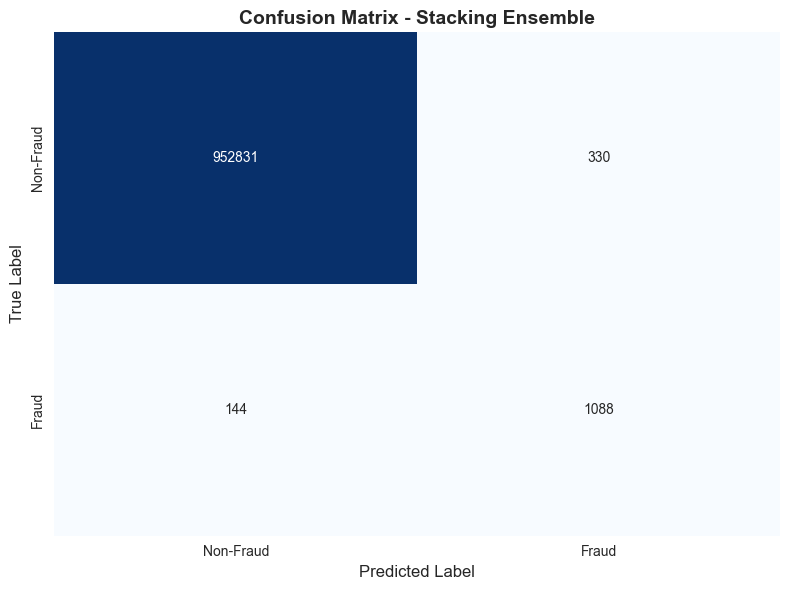

✓ Saved: stacking_ensemble_confusion_matrix.png


In [27]:
# Confusion Matrix
cm = confusion_matrix(ytest_xgb, pred_stack_test)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Non-Fraud', 'Fraud'], 
            yticklabels=['Non-Fraud', 'Fraud'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Stacking Ensemble', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'stacking_ensemble_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: stacking_ensemble_confusion_matrix.png")

### 2. ROC Curve

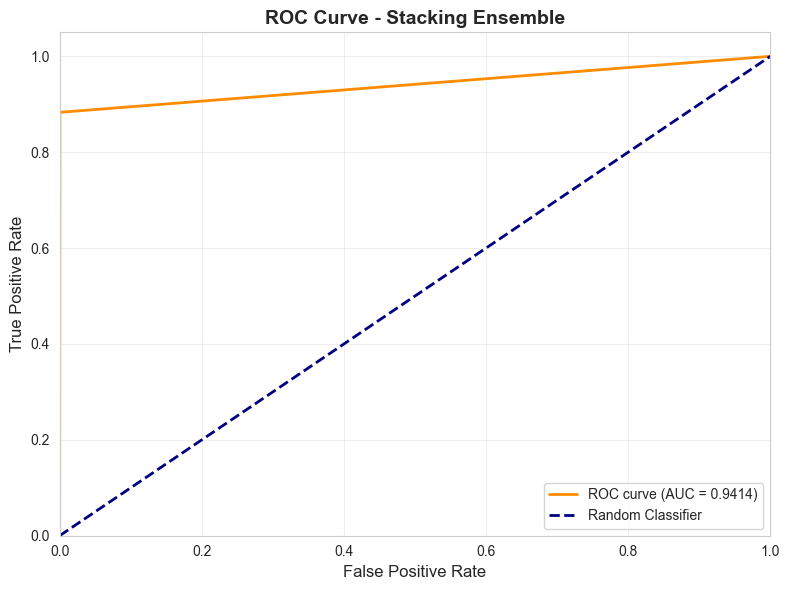

✓ Saved: stacking_ensemble_roc_curve.png


In [28]:
# ROC Curve
fpr, tpr, _ = roc_curve(ytest_xgb, pred_stack_test)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Stacking Ensemble', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'stacking_ensemble_roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: stacking_ensemble_roc_curve.png")

### 3. Precision-Recall Curve

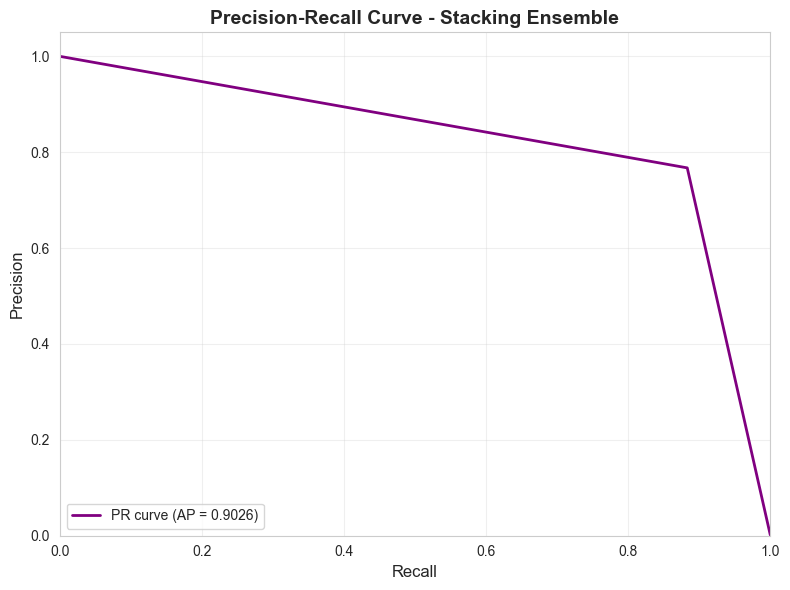

✓ Saved: stacking_ensemble_pr_curve.png


In [29]:
pr_auc = average_precision_score(ytest_xgb, p_stack_test)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ytest_xgb, pred_stack_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve - Stacking Ensemble', fontsize=14, fontweight='bold')
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'stacking_ensemble_pr_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: stacking_ensemble_pr_curve.png")

### 4. Feature Importance (Coefficients)

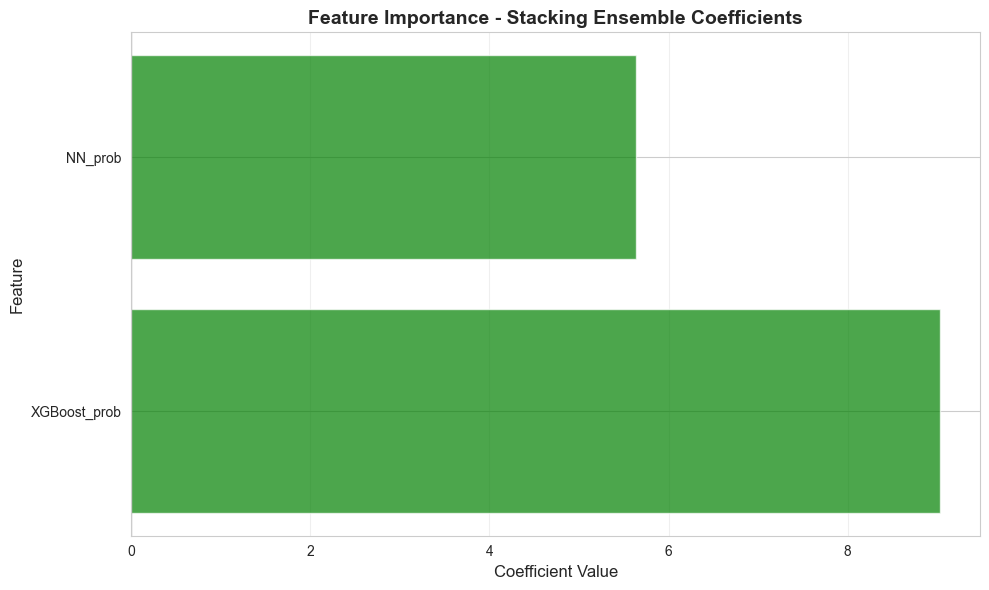

✓ Saved: stacking_ensemble_feature_importance.png


In [30]:
# Feature Importance
meta_feature_names = ["XGBoost_prob", "NN_prob"]

feature_importance = pd.DataFrame({
    "Feature": meta_feature_names,
    "Coefficient": meta.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
ax.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors, alpha=0.7)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance - Stacking Ensemble Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'stacking_ensemble_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: stacking_ensemble_feature_importance.png")

### 5. Save Metrics to CSV

In [31]:
f1 = f1_score(ytest_xgb, pred_stack_test, zero_division=0)

# Save F1 and PR-AUC to CSV for Streamlit
metrics_data = {
    'Metric': ['F1-Score', 'PR-AUC'],
    'Value': [
        f1,
        pr_auc,
    ]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(os.path.join(plots_dir, 'stacking_ensemble_metrics.csv'), index=False)
print("✓ Saved: stacking_ensemble_metrics.csv (F1-Score, PR-AUC)")
print("\nMetrics Summary:")
print(metrics_df.to_string(index=False))

✓ Saved: stacking_ensemble_metrics.csv (F1-Score, PR-AUC)

Metrics Summary:
  Metric    Value
F1-Score 0.821132
  PR-AUC 0.902609


## Explainable AI

In [71]:
# ============================================================
# EXPLAINABLE AI: NN + XGBoost + Meta-Model → Ensemble Feature Importance
# ============================================================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import shap, xgboost as xgb
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42
rng = np.random.RandomState(RANDOM_STATE)

plots_dir = "../plots"
os.makedirs(plots_dir, exist_ok=True)

In [ ]:
# Helper: unified NN probability function
def nn_prob(model, X: np.ndarray) -> np.ndarray:
    p = np.asarray(model.predict(X, verbose=0))
    if p.ndim == 2 and p.shape[1] == 1:  # sigmoid
        return p.ravel()
    if p.ndim == 2 and p.shape[1] == 2:  # softmax
        return p[:, 1]
    if p.ndim == 1:
        return p
    raise ValueError(f"Unexpected Keras output shape: {p.shape}")

In [ ]:
# 1) Ensure meta-model exists (Logistic Regression on [p_xgb, p_nn])
# Build validation prediction matrix
if 'p_xgb_val' not in globals():
    p_xgb_val = xgb_model.predict_proba(Xval_xgb)[:, 1]
if 'p_nn_val' not in globals():
    p_nn_val = nn_prob(nn_model, Xval_nn)

P_val = np.column_stack([p_xgb_val, p_nn_val])  # order: [XGBoost_prob, NN_prob]
meta_feature_names = ["XGBoost_prob", "NN_prob"]

if 'meta' not in globals():
    meta = LogisticRegression(C=1.0, solver="lbfgs", max_iter=200, random_state=RANDOM_STATE)
    meta.fit(P_val, yval_xgb if isinstance(yval_xgb, (pd.Series, pd.DataFrame)) else yval_xgb)


In [74]:
# ------------------------------------------------------------
# 2) Align a common validation sample across all explainers
# ------------------------------------------------------------
n = min(len(Xval_xgb), len(Xval_nn))
sample_n = min(100, n)
idx = rng.choice(np.arange(n), size=sample_n, replace=False)

# XGB slice (keep dtypes; important for categorical)
Xval_xgb_sample = Xval_xgb.iloc[idx].copy()
xgb_feature_names = Xval_xgb_sample.columns.tolist()

# NN slice (scaled numeric matrix)
Xval_nn_sample = Xval_nn[idx]
feature_names_nn = X_val_final.columns.tolist()
Xval_nn_df_sample = pd.DataFrame(Xval_nn_sample, columns=feature_names_nn)

# Meta slice
P_val_sample = P_val[idx, :]

### SHAP for NN

/Users/kayi/Documents/NUS/NUS Year 4 Sem 1/DSA4263/hackathon/DSA4263/.venv/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/Users/kayi/Documents/NUS/NUS Year 4 Sem 1/DSA4263/hackathon/DSA4263/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(100, 61))']
  warnings.warn(msg)
/Users/kayi/Documents/NUS/NUS Year 4 Sem 1/DSA4263/hackathon/DSA4263/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(200, 61))']
  warnings.warn(msg)


DeepExplainer failed; fallback to KernelExplainer: in user code:

    File "/Users/kayi/Documents/NUS/NUS Year 4 Sem 1/DSA4263/hackathon/DSA4263/.venv/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 265, in grad_graph  *
        x_grad = tape.gradient(out, shap_rAnD)

    LookupError: gradient registry has no entry for: shap_LeakyRelu



  0%|          | 0/100 [00:00<?, ?it/s]

/var/folders/hz/w33z2_s56bv9417650gj0c5h0000gn/T/ipykernel_11667/3264608098.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_nn * 1000, Xval_nn_df, show=False)


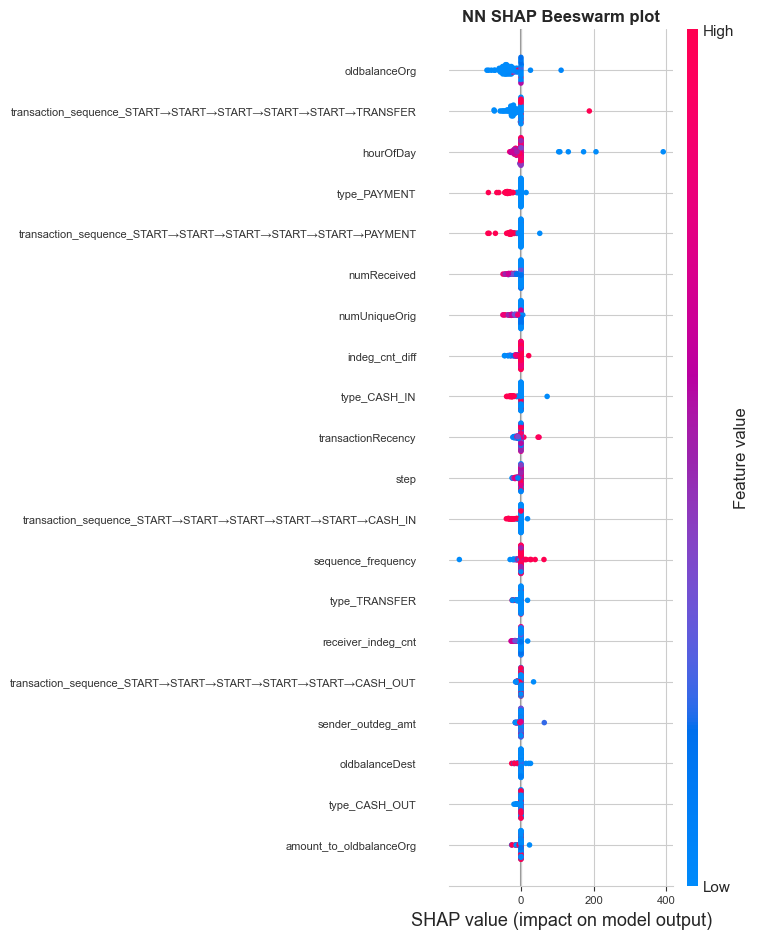

✓ Saved and displayed: nn_shap_beeswarm.png


/var/folders/hz/w33z2_s56bv9417650gj0c5h0000gn/T/ipykernel_11667/3264608098.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_nn*1000, Xval_nn_df, plot_type="bar", show=False)


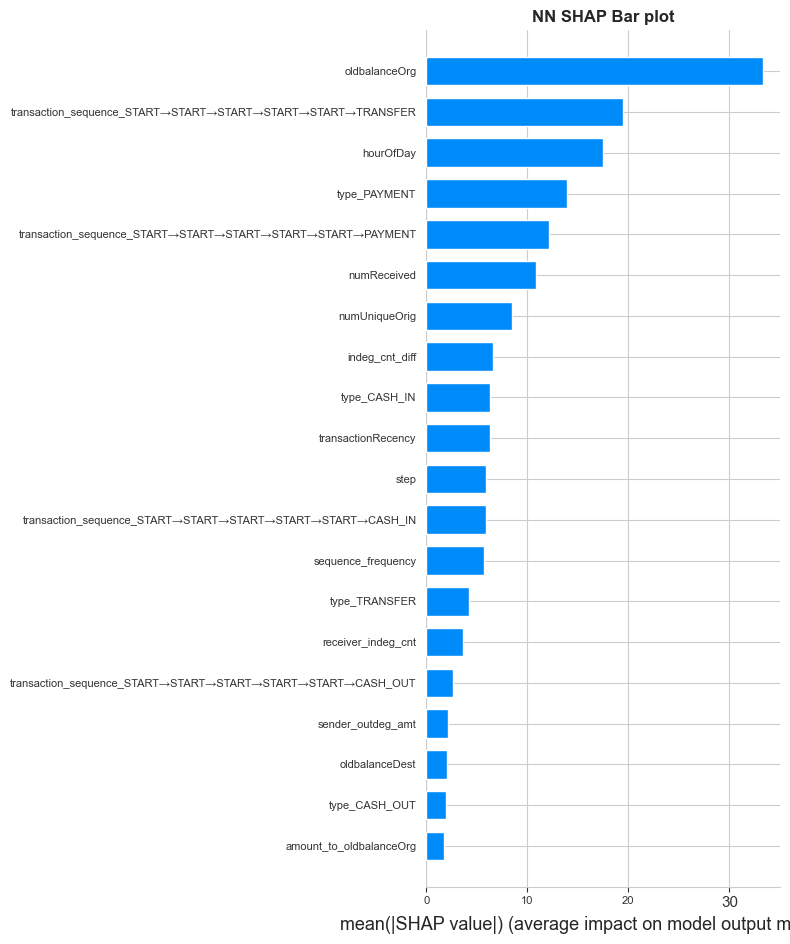

✓ Saved: nn_shap_bar.png


In [75]:
# 3) SHAP for NN
val_sample_size = min(100, Xval_nn.shape[0])
bg_size = min(100, Xtrain_nn.shape[0])
background_nn  = Xtrain_nn[:bg_size]

try:
    explainer_nn = shap.DeepExplainer(nn_model, background_nn)
    shap_values_nn = explainer_nn.shap_values(Xval_nn_sample)
    if isinstance(shap_values_nn, list): shap_values_nn = shap_values_nn[0]
    print("Using DeepExplainer for NN.")
except Exception as e:
    print("DeepExplainer failed; fallback to KernelExplainer:", e)
    explainer_nn = shap.KernelExplainer(lambda x: nn_prob(nn_model, x), background_nn)
    shap_values_nn = explainer_nn.shap_values(Xval_nn_sample, nsamples=100)
    if isinstance(shap_values_nn, list): shap_values_nn = shap_values_nn[0]

Xval_nn_df = pd.DataFrame(Xval_nn_sample, columns=feature_names_nn)

# Beeswarm
plt.figure(figsize=(10,6))
plt.title("NN SHAP Beeswarm plot", fontsize=12, fontweight="bold")
shap.summary_plot(shap_values_nn * 1000, Xval_nn_df, show=False)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.savefig(
    os.path.join(plots_dir, "nn_shap_beeswarm.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("✓ Saved and displayed: nn_shap_beeswarm.png")

# Bar
plt.figure(figsize=(8,5))
plt.title("NN SHAP Bar plot", fontsize=12, fontweight="bold")
shap.summary_plot(shap_values_nn*1000, Xval_nn_df, plot_type="bar", show=False)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "nn_shap_bar.png"), dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: nn_shap_bar.png")


### SHAP for XGBoost

/var/folders/hz/w33z2_s56bv9417650gj0c5h0000gn/T/ipykernel_11667/2021468570.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_xgb, Xval_xgb_sample, feature_names=xgb_feature_names, show=False)


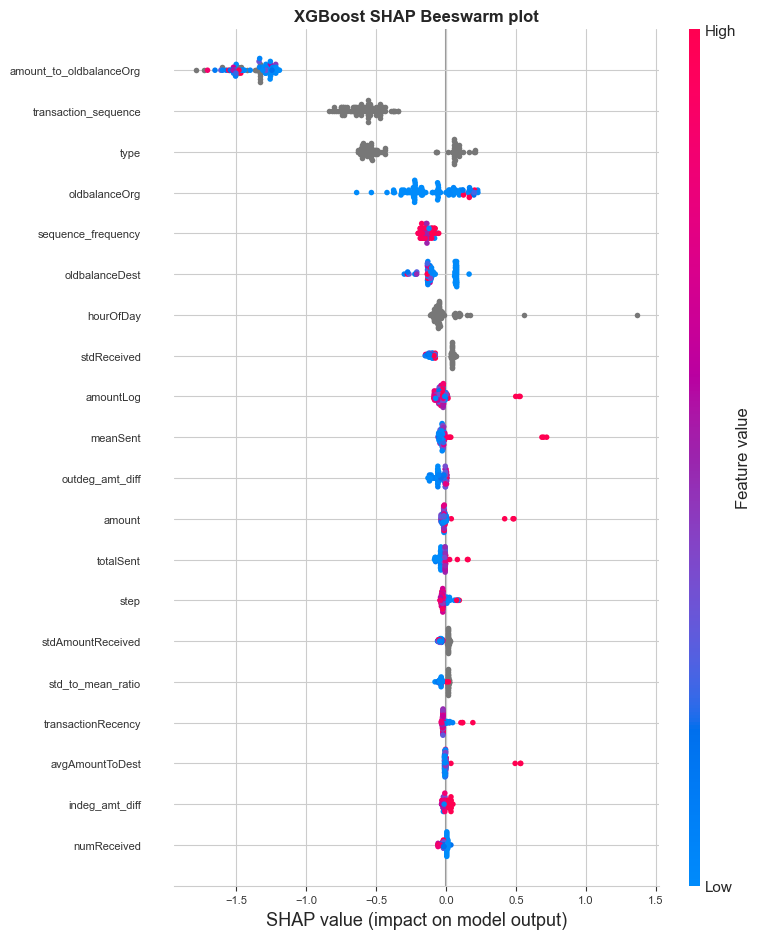

/var/folders/hz/w33z2_s56bv9417650gj0c5h0000gn/T/ipykernel_11667/2021468570.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_xgb, Xval_xgb_sample, feature_names=xgb_feature_names, plot_type="bar", show=False)


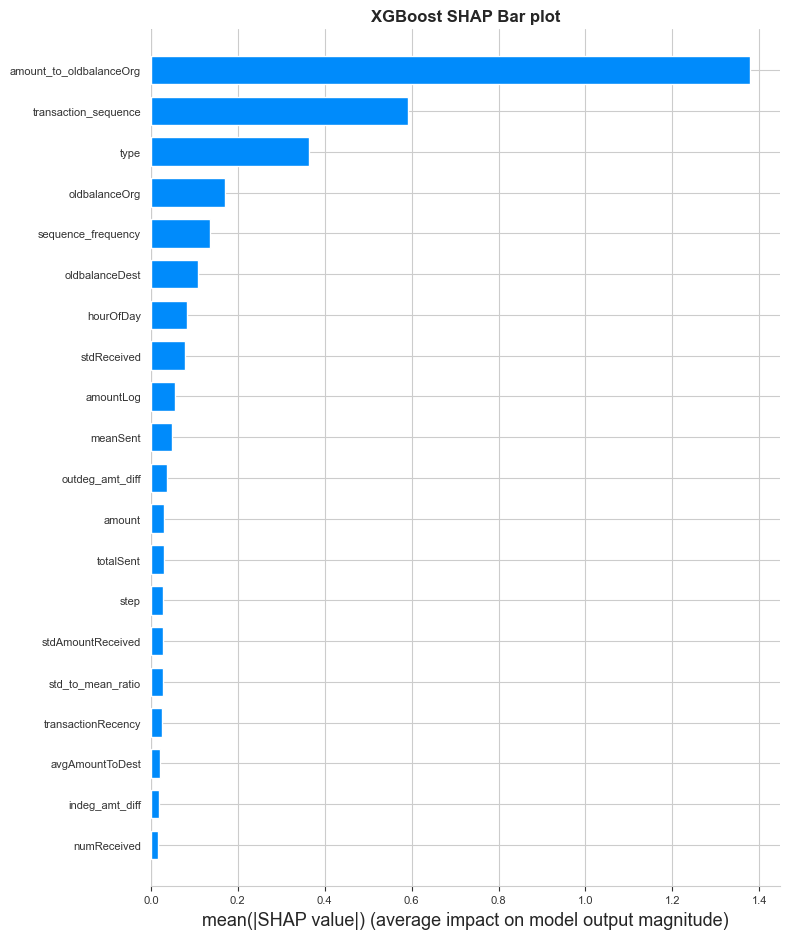

✓ XGBoost SHAP plots saved.


In [76]:
# 4) SHAP for XGBOOST (native pred_contribs on margin/logit)
# Keep categorical dtypes
for c in Xval_xgb_sample.select_dtypes(include='category').columns:
    Xval_xgb_sample[c] = Xval_xgb_sample[c].cat.remove_unused_categories()

dm = xgb.DMatrix(Xval_xgb_sample, enable_categorical=True)
booster = xgb_model.get_booster()
shap_values_xgb_full = booster.predict(dm, pred_contribs=True)  # (n, n_features+1)
shap_values_xgb = shap_values_xgb_full[:, :-1]  # drop bias term

# XGB: Beeswarm & Bar
plt.figure(figsize=(10, 6))
plt.title("XGBoost SHAP Beeswarm plot", fontsize=12, fontweight="bold")
shap.summary_plot(shap_values_xgb, Xval_xgb_sample, feature_names=xgb_feature_names, show=False)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(plots_dir, "xgb_shap_beeswarm.png"), dpi=300); plt.show()

plt.figure(figsize=(8, 5))
plt.title("XGBoost SHAP Bar plot", fontsize=12, fontweight="bold")
shap.summary_plot(shap_values_xgb, Xval_xgb_sample, feature_names=xgb_feature_names, plot_type="bar", show=False)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(plots_dir, "xgb_shap_bar.png"), dpi=300); plt.show()
print("✓ XGBoost SHAP plots saved.")

### SHAP for Meta-Model

Using LinearExplainer for meta-model.


/var/folders/hz/w33z2_s56bv9417650gj0c5h0000gn/T/ipykernel_11667/2976152067.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_meta, P_val_sample, feature_names=meta_feature_names, show=False)


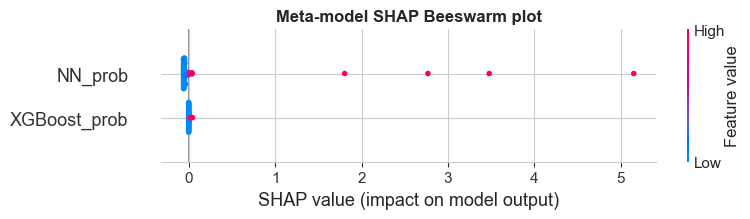

/var/folders/hz/w33z2_s56bv9417650gj0c5h0000gn/T/ipykernel_11667/2976152067.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_meta, P_val_sample, feature_names=meta_feature_names, plot_type="bar", show=False)


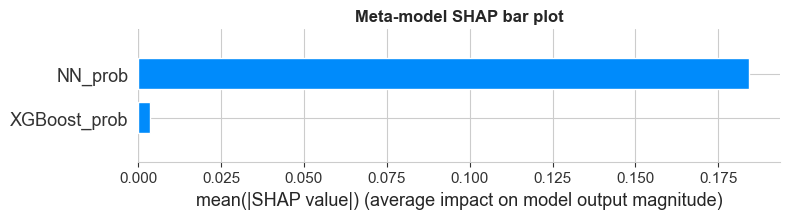

✓ Meta-model SHAP plots saved.


In [77]:
# 5) SHAP for META-MODEL (explains how base probs affect stacker)
try:
    meta_bg = P_val[:200] if P_val.shape[0] > 200 else P_val
    explainer_meta = shap.LinearExplainer(meta, meta_bg)
    shap_values_meta = explainer_meta.shap_values(P_val_sample)
    print("Using LinearExplainer for meta-model.")
except Exception as e:
    print("LinearExplainer failed; fallback to KernelExplainer:", e)
    explainer_meta = shap.KernelExplainer(lambda x: meta.predict_proba(x)[:, 1], P_val_sample[:50])
    shap_values_meta = explainer_meta.shap_values(P_val_sample, nsamples=100)

plt.figure(figsize=(6, 2.2))
plt.title("Meta-model SHAP Beeswarm plot", fontsize=12, fontweight="bold")
shap.summary_plot(shap_values_meta, P_val_sample, feature_names=meta_feature_names, show=False)
plt.tight_layout(); plt.savefig(os.path.join(plots_dir, "meta_shap_beeswarm.png"), dpi=300); plt.show()

plt.figure(figsize=(6, 2.2))
plt.title("Meta-model SHAP bar plot", fontsize=12, fontweight="bold")
shap.summary_plot(shap_values_meta, P_val_sample, feature_names=meta_feature_names, plot_type="bar", show=False)
plt.tight_layout(); plt.savefig(os.path.join(plots_dir, "meta_shap_bar.png"), dpi=300); plt.show()
print("✓ Meta-model SHAP plots saved.")

In [78]:
# ------------------------------------------------------------
# 6) GLOBAL IMPORTANCE PER BASE MODEL
#    - NN: group one-hot back to base features (type, transaction_sequence, typeHighValueFlag)
#    - XGB: mean(|SHAP|) across samples
# ------------------------------------------------------------
# Mean absolute SHAP per feature
xgb_importance = pd.Series(np.abs(shap_values_xgb).mean(axis=0), index=xgb_feature_names)

nn_feature_names = Xval_nn_df_sample.columns.tolist()
nn_abs = pd.Series(np.abs(shap_values_nn).mean(axis=0), index=nn_feature_names)

# Group NN OHE columns to base features for interpretability
def base_name(col: str) -> str:
    for prefix in ['type_', 'transaction_sequence_', 'typeHighValueFlag_']:
        if col.startswith(prefix):
            return prefix[:-1]  # remove trailing underscore
    return col

nn_grouped_importance = nn_abs.groupby(nn_abs.index.map(base_name)).sum()

# Save per-model importances
xgb_importance.sort_values(ascending=False).to_csv(os.path.join(plots_dir, "xgb_feature_importance_mean_abs_shap.csv"))
nn_grouped_importance.sort_values(ascending=False).to_csv(os.path.join(plots_dir, "nn_feature_importance_grouped_mean_abs_shap.csv"))


### META INFLUENCE WEIGHTS & ENSEMBLE FEATURE IMPORTANCE

Meta weights (from SHAP): {'XGBoost_prob': 0.019, 'NN_prob': 0.981}


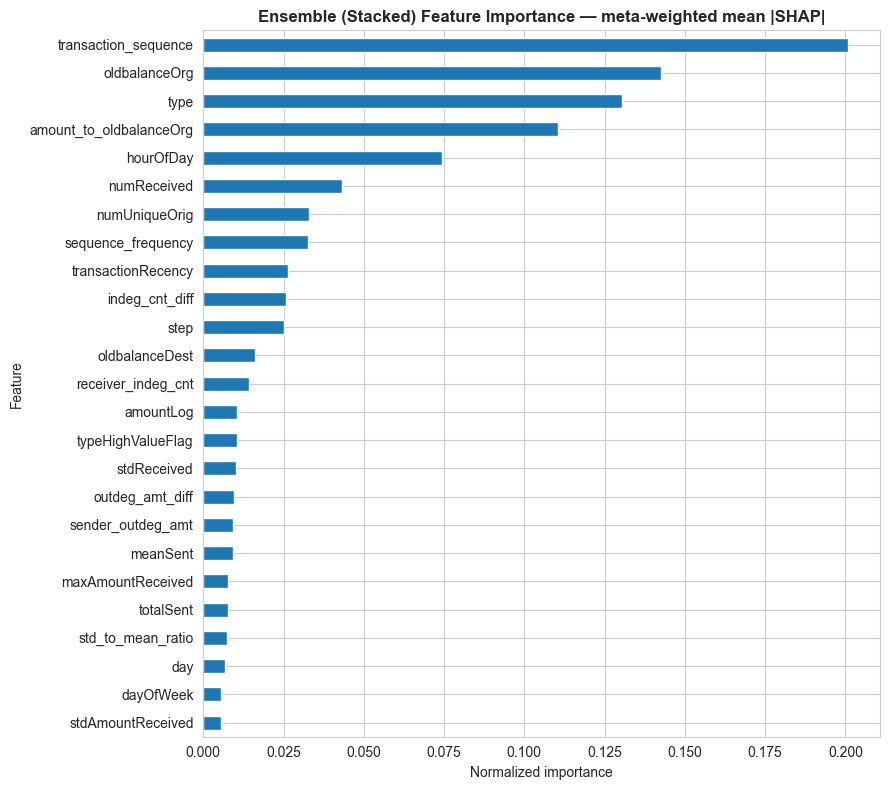

✓ Ensemble feature importance saved (CSV & PNG).


In [79]:
# ------------------------------------------------------------
# 7) META INFLUENCE WEIGHTS & ENSEMBLE FEATURE IMPORTANCE
#    We weight base-model importances by how much the meta-model relies on each base prob.
#    Use meta SHAP means (preferred) → normalize to sum=1 as weights.
# ------------------------------------------------------------
meta_shap_means = pd.Series(np.abs(shap_values_meta).mean(axis=0), index=meta_feature_names)
meta_weights = meta_shap_means / meta_shap_means.sum()
w_xgb = float(meta_weights.get("XGBoost_prob", 0.0))
w_nn  = float(meta_weights.get("NN_prob", 0.0))
print("Meta weights (from SHAP):", {"XGBoost_prob": round(w_xgb, 4), "NN_prob": round(w_nn, 4)})

# Put both importances on the same feature index
all_features = sorted(set(xgb_importance.index).union(set(nn_grouped_importance.index)))
xgb_imp_aligned = xgb_importance.reindex(all_features).fillna(0.0)
nn_imp_aligned  = nn_grouped_importance.reindex(all_features).fillna(0.0)

# Meta-weighted ensemble feature importance
ensemble_importance = w_xgb * xgb_imp_aligned + w_nn * nn_imp_aligned
ensemble_importance_norm = ensemble_importance / ensemble_importance.sum()

# Save & plot top-k
topk = 25
ens_top = ensemble_importance_norm.sort_values(ascending=False).head(topk)
ens_top.to_csv(os.path.join(plots_dir, "ensemble_feature_importance_top25.csv"), header=["normalized_importance"])

plt.figure(figsize=(9, 8))
ens_top.sort_values().plot(kind="barh")
plt.title("Ensemble (Stacked) Feature Importance — meta-weighted mean |SHAP|", fontsize=12, fontweight="bold")
plt.xlabel("Normalized importance"); plt.ylabel("Feature")
plt.tight_layout(); plt.savefig(os.path.join(plots_dir, "ensemble_feature_importance_top25.png"), dpi=300); plt.show()
print("✓ Ensemble feature importance saved (CSV & PNG).")

## Appendix: weighted average ensemble

In [32]:
# Search w in [0,1] for: p = w*p_xgb + (1-w)*p_nn
ws = np.linspace(0, 1, 101)
best = {"w": None, "score": -np.inf, "metric": "pr_auc"}

for w in ws:
    p_val = w * p_xgb_val + (1 - w) * p_nn_val
    score = average_precision_score(yval_xgb, p_val)  # use PR AUC for imbalanced tasks
    if score > best["score"]:
        best.update({"w": float(w), "score": float(score)})

w_best = best["w"]
p_wavg_val = w_best * p_xgb_val + (1 - w_best) * p_nn_val

# Tune decision threshold for chosen policy (F-beta)
thr_wavg, fbest = tune_threshold_fbeta(yval_xgb, p_wavg_val, beta=1.0)  # set beta>1 to favor recall
wavg_val_metrics = calculate_metrics(yval_xgb, p_wavg_val, thr=thr_wavg)
wavg_val_metrics.update({"weight_xgb": w_best, "weight_nn": 1 - w_best, "fbeta_best": fbest})

print(f"weight = {w_best}")

print("Validation — Weighted Avg:", wavg_val_metrics)

weight = 1.0
Validation — Weighted Avg: {'accuracy': 0.9997852037892148, 'pr_auc': 0.9694191926896643, 'f1@thr': 0.9150435142975549, 'precision@thr': 0.934801016088061, 'recall@thr': 0.8961038961038961, 'threshold': 0.9830347299575806, 'weight_xgb': 1.0, 'weight_nn': 0.0, 'fbeta_best': 0.9154228855721394}
